<a href="https://colab.research.google.com/github/HimanshiChoubal/AI-for-Compiler-/blob/main/Compiler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import os
import subprocess
import random
import pandas as pd

# 1. Setup - Scaled up for proper Deep Learning generalization
DATASET_SIZE = 5000
OUTPUT_DIR = "temp_samples"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Ensure clang is installed
!apt-get install -y clang > /dev/null

def generate_dataset():
    data_pairs = []
    print(f"Generating {DATASET_SIZE} samples using symbolic variables...")

    for i in range(DATASET_SIZE):
        # Use variables instead of integers to prevent "Constant Folding" failures
        vars_list = ['a', 'b', 'c', 'd', 'e', 'f']
        ops = ['+', '-', '*']

        v1, v2, v3 = random.sample(vars_list, 3)
        expr = f"{v1} {random.choice(ops)} {v2} {random.choice(ops)} {v3}"

        # Pass the variables into the function signature
        c_code = f"int predictor(int a, int b, int c, int d, int e, int f) {{ return {expr}; }}"

        c_file = os.path.join(OUTPUT_DIR, f"test_{i}.c")
        s_file = os.path.join(OUTPUT_DIR, f"test_{i}.s")

        with open(c_file, "w") as f:
            f.write(c_code)

        # Compile with -O1 so clang maps variables to registers cleanly
        result = subprocess.run(["clang", "-S", "-O1", c_file, "-o", s_file])

        if result.returncode == 0 and os.path.exists(s_file):
            with open(s_file, "r") as f:
                # Extract only the actual assembly instructions
                lines = [l.strip() for l in f.readlines() if l.strip() and not l.strip().startswith('.')]
                asm_string = " | ".join(lines)
                data_pairs.append({"c_expression": expr, "assembly_code": asm_string})

    if len(data_pairs) > 0:
        df = pd.DataFrame(data_pairs)
        df.to_csv("compiler_dataset.csv", index=False)
        print(f"Done! Created compiler_dataset.csv with {len(df)} samples.")
    else:
        print("Error: No data generated.")

generate_dataset()

Generating 5000 samples using symbolic variables...
Done! Created compiler_dataset.csv with 5000 samples.


In [32]:
# ── Cell 1: Installs & Imports ───────────────────────────────────────────────
!pip install torch torchtext --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import pandas as pd
import numpy as np
import random, time, math
import matplotlib.pyplot as plt
from collections import Counter

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [33]:
# ── Cell 2: Vocabulary & Tokenizer ───────────────────────────────────────────
PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN = "<PAD>", "<SOS>", "<EOS>", "<UNK>"
SPECIAL_TOKENS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

class Vocabulary:
    def __init__(self):
        self.token2idx = {t: i for i, t in enumerate(SPECIAL_TOKENS)}
        self.idx2token = {i: t for t, i in self.token2idx.items()}

    def build(self, sentences, min_freq=1):
        counts = Counter(tok for sent in sentences for tok in sent)
        for tok, freq in counts.items():
            if freq >= min_freq and tok not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[tok] = idx
                self.idx2token[idx] = tok

    def encode(self, tokens):
        return [self.token2idx.get(t, self.token2idx[UNK_TOKEN]) for t in tokens]

    def decode(self, indices):
        return [self.idx2token.get(i, UNK_TOKEN) for i in indices]

    def __len__(self):
        return len(self.token2idx)

def simple_tokenize(text):
    """Character-level tokenizer — swap for subword if needed."""
    # Split on spaces; further split common operators as individual tokens
    import re
    tokens = re.findall(r'[a-zA-Z_]\w*|[\d]+|[^\s\w]', text.strip())
    return tokens

# Quick test
print(simple_tokenize("a + b * c"))
print(simple_tokenize("MOV EAX, [EBP-4]"))

['a', '+', 'b', '*', 'c']
['MOV', 'EAX', ',', '[', 'EBP', '-', '4', ']']


In [34]:
# ── Cell 3: Dataset ──────────────────────────────────────────────────────────
class CompilerDataset(Dataset):
    def __init__(self, df, src_vocab, tgt_vocab, max_len=50):
        self.max_len = max_len
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.pairs = []

        sos = tgt_vocab.token2idx[SOS_TOKEN]
        eos = tgt_vocab.token2idx[EOS_TOKEN]

        for _, row in df.iterrows():
            src_tokens = simple_tokenize(str(row["c_expression"]))[:max_len]
            tgt_tokens = simple_tokenize(str(row["assembly_code"]))[:max_len]

            src_ids = torch.tensor(src_vocab.encode(src_tokens), dtype=torch.long)
            tgt_ids = torch.tensor([sos] + tgt_vocab.encode(tgt_tokens) + [eos], dtype=torch.long)
            self.pairs.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_padded = pad_sequence(src_batch, batch_first=True,
                              padding_value=0)   # PAD_TOKEN index = 0
    tgt_padded = pad_sequence(tgt_batch, batch_first=True,
                              padding_value=0)
    return src_padded, tgt_padded

# ── Load CSV & build vocabularies ────────────────────────────────────────────
df = pd.read_csv("compiler_dataset.csv")
print(f"Dataset size: {len(df)} rows")
print(df.head(3))

# 90/10 train-val split
split = int(0.9 * len(df))
train_df = df.iloc[:split].reset_index(drop=True)
val_df   = df.iloc[split:].reset_index(drop=True)

src_vocab = Vocabulary()
tgt_vocab = Vocabulary()

all_src = [simple_tokenize(str(s)) for s in df["c_expression"]]
all_tgt = [simple_tokenize(str(s)) for s in df["assembly_code"]]
src_vocab.build(all_src)
tgt_vocab.build(all_tgt)

print(f"Source vocab size: {len(src_vocab)}")
print(f"Target vocab size: {len(tgt_vocab)}")

BATCH_SIZE = 64
train_ds = CompilerDataset(train_df, src_vocab, tgt_vocab)
val_ds   = CompilerDataset(val_df,   src_vocab, tgt_vocab)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Dataset size: 5000 rows
  c_expression                                      assembly_code
0    d + f * a  predictor:                              # @pre...
1    a * d * f  predictor:                              # @pre...
2    d - f + e  predictor:                              # @pre...
Source vocab size: 13
Target vocab size: 42


In [35]:
# ── Cell 4: Model Architecture ───────────────────────────────────────────────

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=dropout, bidirectional=True)
        # Project bidirectional hidden → hidden_dim for decoder
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (B, T)
        embedded = self.dropout(self.embedding(src))        # (B, T, E)
        outputs, hidden = self.gru(embedded)                # outputs: (B, T, 2H)
        # Combine last-layer bidirectional hidden states
        # hidden shape: (num_layers*2, B, H)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1) # (B, 2H)
        hidden = torch.tanh(self.fc(hidden)).unsqueeze(0)   # (1, B, H)
        return outputs, hidden                              # encoder_outputs, context


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn   = nn.Linear(hidden_dim * 3, hidden_dim)   # enc is 2H, dec is H
        self.v      = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: (1, B, H) → (B, 1, H)
        # encoder_outputs: (B, T, 2H)
        B, T, _ = encoder_outputs.shape
        dec_h = decoder_hidden.permute(1, 0, 2).expand(-1, T, -1)   # (B, T, H)
        energy = torch.tanh(self.attn(torch.cat([dec_h, encoder_outputs], dim=2)))  # (B, T, H)
        attention = self.v(energy).squeeze(2)                         # (B, T)
        return torch.softmax(attention, dim=1)                        # (B, T)


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention  = BahdanauAttention(hidden_dim)
        # input = embedded + context vector (2H from encoder)
        self.gru = nn.GRU(embed_dim + hidden_dim * 2, hidden_dim,
                          num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc_out = nn.Linear(hidden_dim * 3 + embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, decoder_hidden, encoder_outputs):
        # tgt_token: (B,) — current input token
        tgt_token = tgt_token.unsqueeze(1)                       # (B, 1)
        embedded   = self.dropout(self.embedding(tgt_token))     # (B, 1, E)

        attn_weights = self.attention(decoder_hidden, encoder_outputs)  # (B, T)
        attn_weights = attn_weights.unsqueeze(1)                         # (B, 1, T)
        context = torch.bmm(attn_weights, encoder_outputs)               # (B, 1, 2H)

        rnn_input = torch.cat([embedded, context], dim=2)                # (B, 1, E+2H)
        output, decoder_hidden = self.gru(rnn_input, decoder_hidden)     # (B, 1, H)

        prediction = self.fc_out(
            torch.cat([output, context, embedded], dim=2)
        ).squeeze(1)                                                      # (B, vocab)
        return prediction, decoder_hidden, attn_weights.squeeze(1)


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tgt_vocab_size, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device
        self.tgt_vocab_size = tgt_vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        B, T_tgt = tgt.shape
        outputs = torch.zeros(B, T_tgt, self.tgt_vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src)
        dec_input = tgt[:, 0]       # <SOS>

        for t in range(1, T_tgt):
            pred, hidden, _ = self.decoder(dec_input, hidden, encoder_outputs)
            outputs[:, t] = pred
            use_teacher = random.random() < teacher_forcing_ratio
            dec_input = tgt[:, t] if use_teacher else pred.argmax(dim=1)

        return outputs

# ── Instantiate ──────────────────────────────────────────────────────────────
EMBED_DIM  = 128
HIDDEN_DIM = 256

encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM).to(DEVICE)
decoder = Decoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM).to(DEVICE)
model   = Seq2Seq(encoder, decoder, len(tgt_vocab), DEVICE).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 2,838,442


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


In [36]:
# ── Cell 5: Training Loop ────────────────────────────────────────────────────
PAD_IDX = tgt_vocab.token2idx[PAD_TOKEN]

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def run_epoch(model, loader, criterion, optimizer=None, teacher_ratio=0.5):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0

    with torch.set_grad_enabled(is_train):
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            output = model(src, tgt, teacher_forcing_ratio=teacher_ratio if is_train else 0.0)
            # output: (B, T, V) — ignore first timestep (SOS target)
            output = output[:, 1:].reshape(-1, output.shape[-1])
            target = tgt[:, 1:].reshape(-1)
            loss = criterion(output, target)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(loader)

# ── Train ────────────────────────────────────────────────────────────────────
NUM_EPOCHS = 30
train_losses, val_losses = [], []
best_val_loss = float("inf")

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train PPL':>12} {'Val Loss':>10} {'Val PPL':>10} {'Time':>8}")
print("-" * 64)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    # Gradually reduce teacher forcing
    tf_ratio = max(0.3, 1.0 - epoch * 0.02)
    train_loss = run_epoch(model, train_loader, criterion, optimizer, tf_ratio)
    val_loss   = run_epoch(model, val_loader,   criterion)

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    elapsed = time.time() - t0
    print(f"{epoch:>6} {train_loss:>12.4f} {math.exp(train_loss):>12.2f} "
          f"{val_loss:>10.4f} {math.exp(val_loss):>10.2f} {elapsed:>7.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("   ✓ Saved best model")

print(f"\nBest validation loss: {best_val_loss:.4f}")

 Epoch   Train Loss    Train PPL   Val Loss    Val PPL     Time
----------------------------------------------------------------
     1       0.8526         2.35     1.7684       5.86     8.8s
   ✓ Saved best model
     2       0.0560         1.06     0.0091       1.01     9.7s
   ✓ Saved best model
     3       0.0082         1.01     0.0028       1.00     9.7s
   ✓ Saved best model
     4       0.0040         1.00     0.0014       1.00    10.0s
   ✓ Saved best model
     5       0.0021         1.00     0.0008       1.00     9.9s
   ✓ Saved best model
     6       0.0013         1.00     0.0006       1.00     9.5s
   ✓ Saved best model
     7       0.0009         1.00     0.0005       1.00     9.6s
   ✓ Saved best model
     8       0.0181         1.02     0.0018       1.00     9.7s
     9       0.0013         1.00     0.0006       1.00     9.5s
    10       0.0007         1.00     0.0004       1.00     9.2s
   ✓ Saved best model
    11       0.0006         1.00     0.0003       1.00 

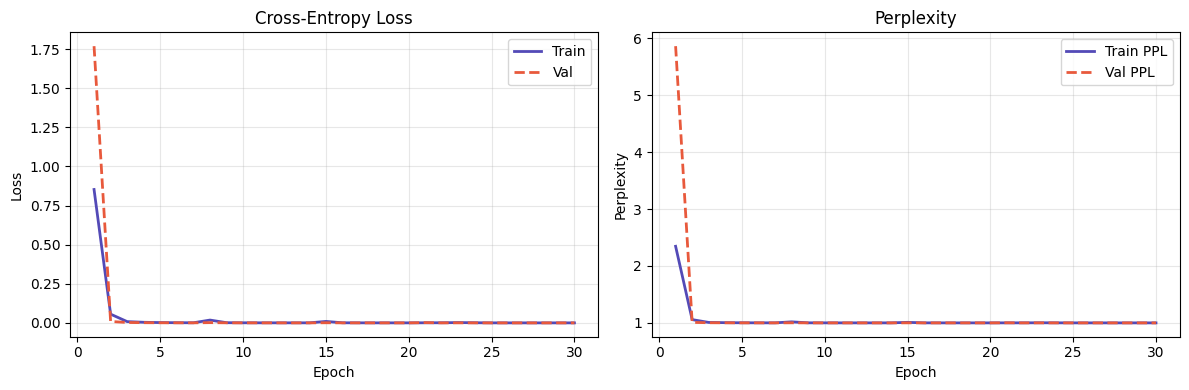

Plot saved to training_curves.png


In [37]:
# ── Cell 6: Loss Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label="Train", color="#534AB7", linewidth=2)
axes[0].plot(epochs_range, val_losses,   label="Val",   color="#E8593C", linewidth=2, linestyle="--")
axes[0].set_title("Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [math.exp(l) for l in train_losses], label="Train PPL", color="#534AB7", linewidth=2)
axes[1].plot(epochs_range, [math.exp(l) for l in val_losses],   label="Val PPL",   color="#E8593C", linewidth=2, linestyle="--")
axes[1].set_title("Perplexity")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to training_curves.png")

In [38]:
# ── Cell 7: Inference ────────────────────────────────────────────────────────
def translate(c_expression: str, max_len: int = 50):
    """Translate a C expression string to predicted assembly."""
    model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
    model.eval()

    src_tokens = simple_tokenize(c_expression)
    src_ids = torch.tensor(
        [src_vocab.token2idx.get(t, src_vocab.token2idx[UNK_TOKEN]) for t in src_tokens],
        dtype=torch.long
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_ids)

    sos_idx = tgt_vocab.token2idx[SOS_TOKEN]
    eos_idx = tgt_vocab.token2idx[EOS_TOKEN]
    dec_input = torch.tensor([sos_idx], dtype=torch.long).to(DEVICE)

    predicted_tokens, attention_weights = [], []

    for _ in range(max_len):
        with torch.no_grad():
            pred, hidden, attn = model.decoder(dec_input, hidden, encoder_outputs)

        top_token = pred.argmax(dim=1).item()

        # CRITICAL FIX: Stop immediately when EOS is generated to prevent looping
        if top_token == eos_idx:
            break

        predicted_tokens.append(top_token)
        attention_weights.append(attn.squeeze(0).cpu().numpy())
        dec_input = torch.tensor([top_token], dtype=torch.long).to(DEVICE)

    decoded = tgt_vocab.decode(predicted_tokens)
    return " ".join(decoded), attention_weights, src_tokens

# ── Try it out ───────────────────────────────────────────────────────────────
# Test with symbolic variables to match our new dataset
test_expressions = [
    "a + b",
    "c * d - a",
    "f - e + b * c",
]

for expr in test_expressions:
    result, attn, _ = translate(expr)
    print(f"  Input : {expr}")
    print(f"  Output: {result}")
    print()

  Input : a + b
  Output: predictor : # @ predictor | # % bb . 0 : | # kill : def $ esi killed $ esi def $ rsi | # kill : def $ edi killed $ edi def $ rdi | leal ( % rdi , % rsi ) , % eax

  Input : c * d - a
  Output: predictor : # @ predictor | # % bb . 0 : | movl % edx , % eax | imull % ecx , % eax | subl % edi , % eax | retq | # - - End function

  Input : f - e + b * c
  Output: predictor : # @ predictor | # % bb . 0 : | # kill : def $ r9d killed $ r9d def $ r9 | # kill : def $ esi killed $ esi def $ rsi | imull % r8d , % esi | leal ( % rsi



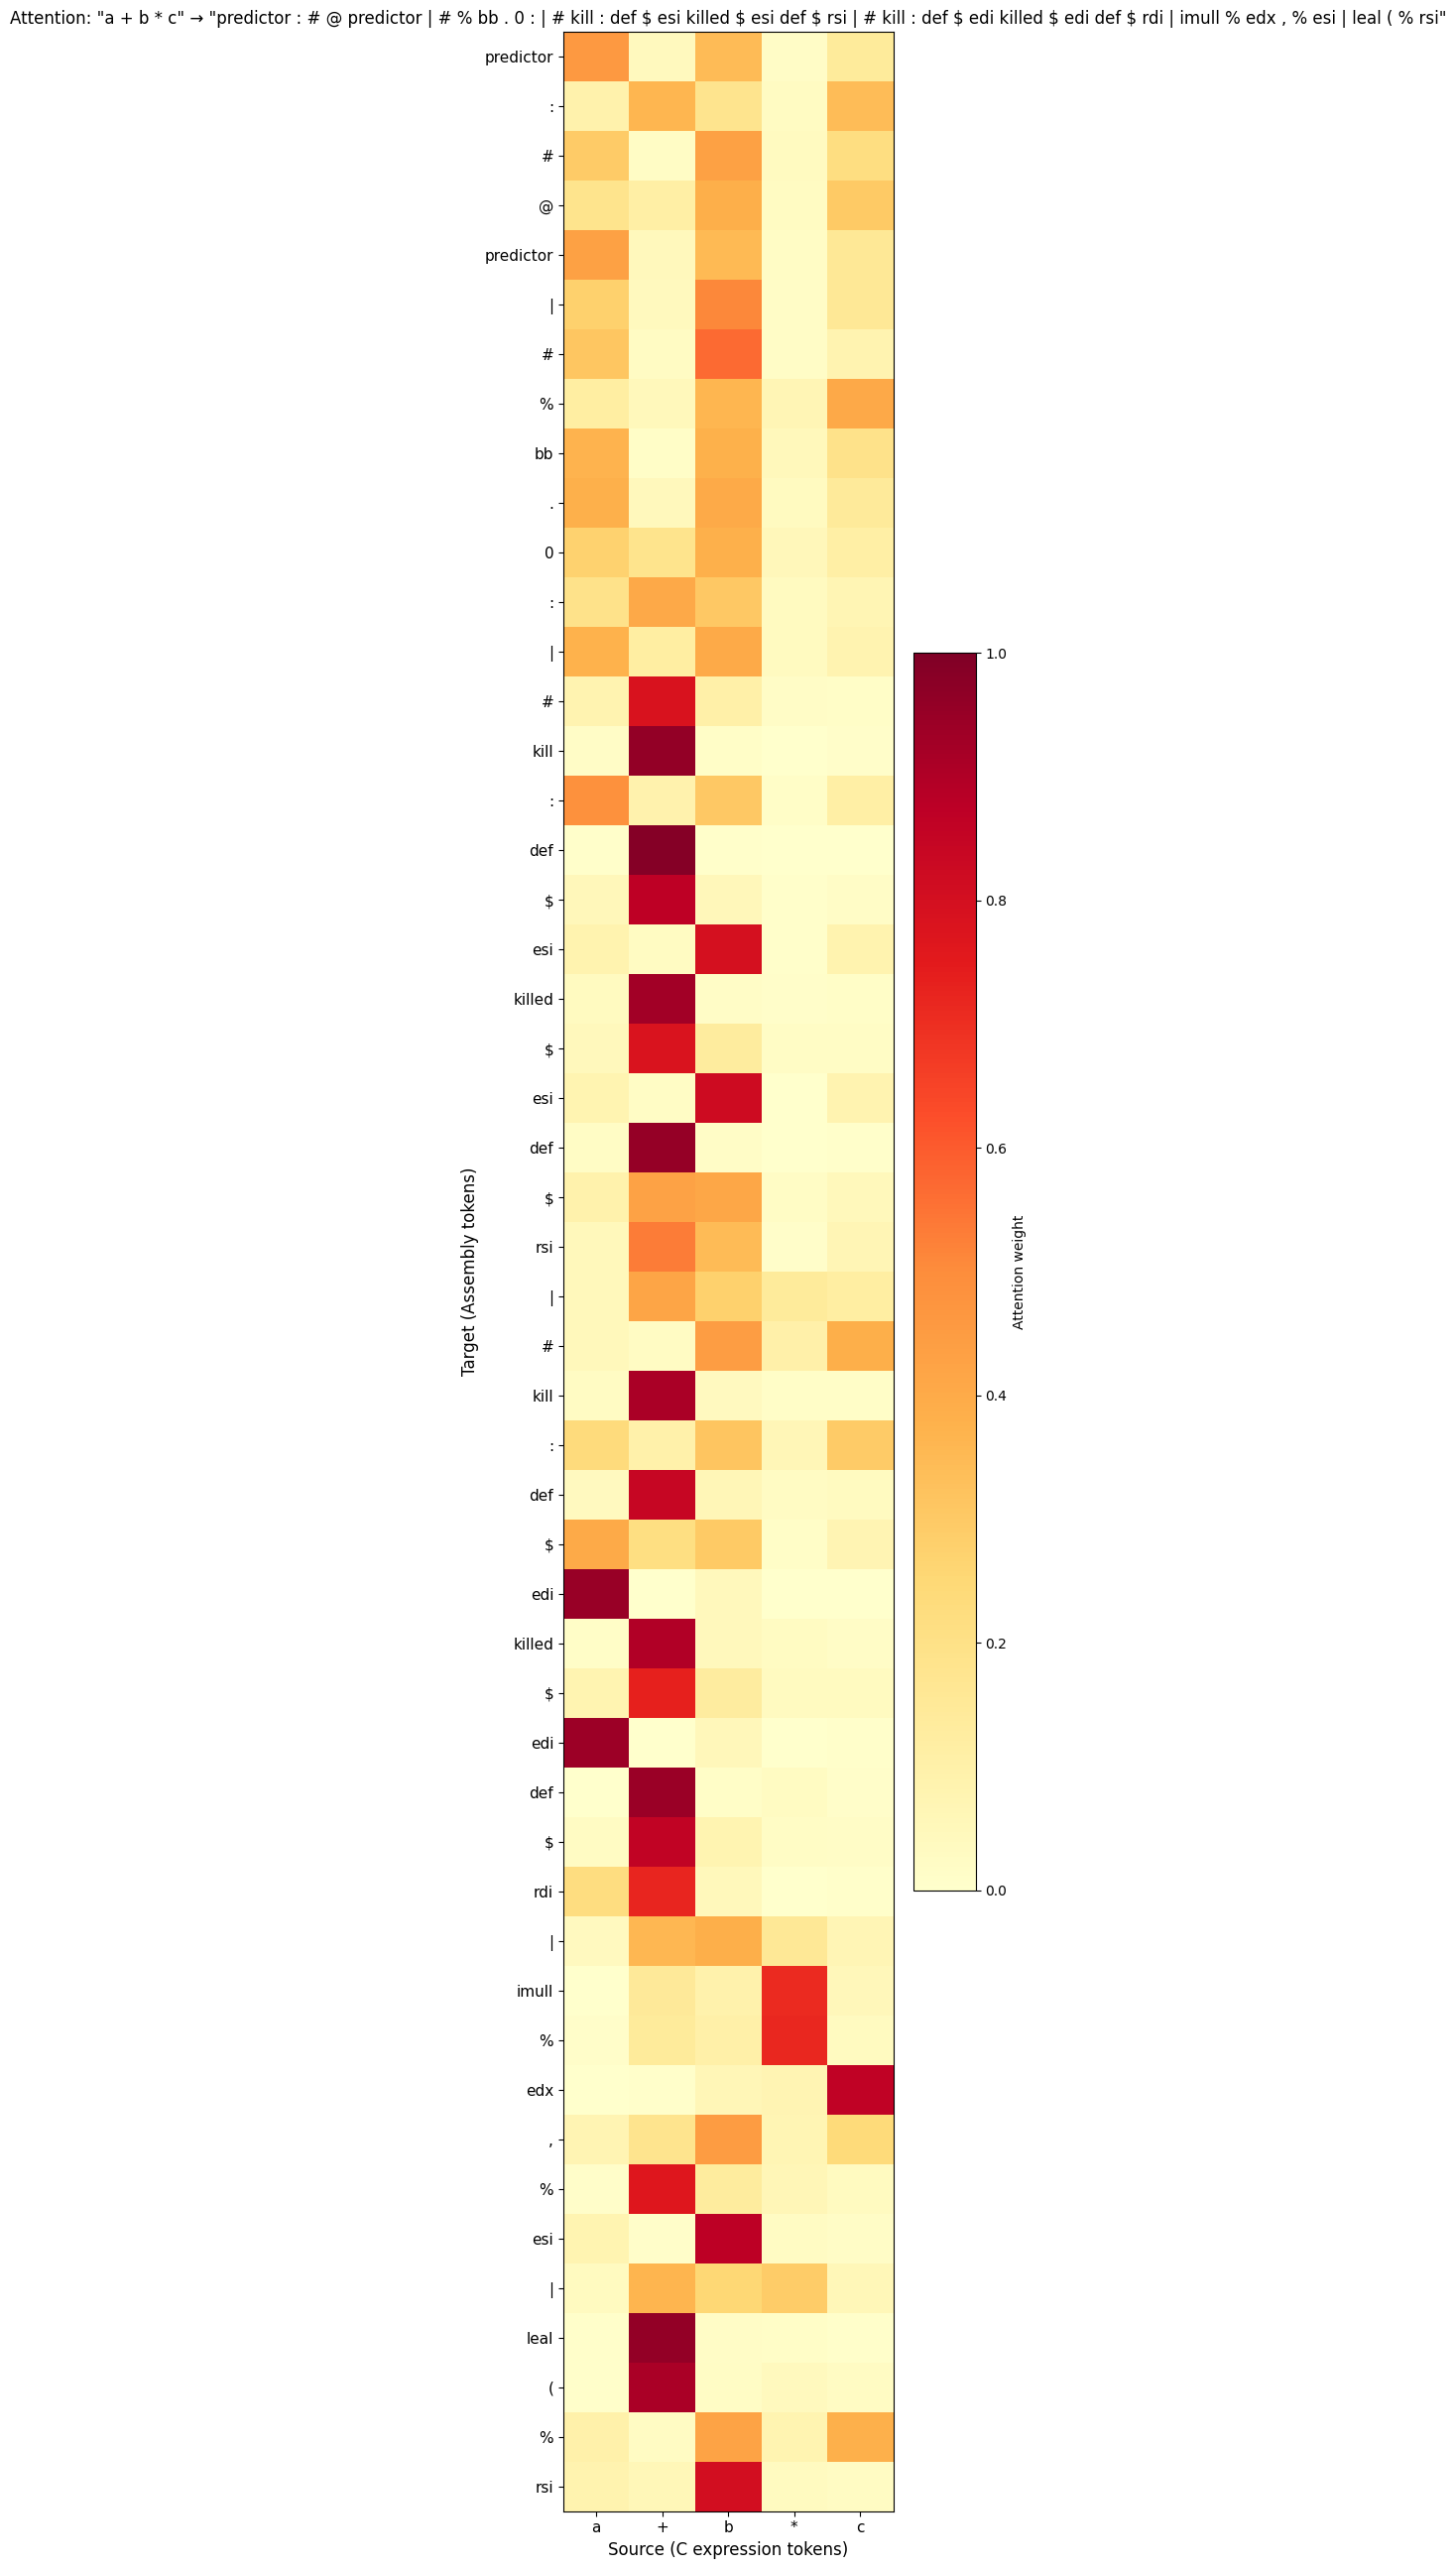

In [39]:
# ── Cell 8: Attention Heatmap ────────────────────────────────────────────────
def plot_attention(c_expression: str):
    output_str, attn_weights, src_tokens = translate(c_expression)
    output_tokens = output_str.split()

    if not attn_weights:
        print("No attention weights to plot.")
        return

    attn_matrix = np.stack(attn_weights)          # (out_len, src_len)
    # Trim to valid token range
    attn_matrix = attn_matrix[:, :len(src_tokens)]

    fig, ax = plt.subplots(figsize=(max(6, len(src_tokens)), max(4, len(output_tokens) * 0.5 + 1)))
    im = ax.imshow(attn_matrix, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels([t.replace('$', '\\$') for t in src_tokens], fontsize=11)
    ax.set_yticks(range(len(output_tokens)))
    ax.set_yticklabels([t.replace('$', '\\$') for t in output_tokens], fontsize=11)
    ax.set_xlabel("Source (C expression tokens)", fontsize=12)
    ax.set_ylabel("Target (Assembly tokens)", fontsize=12)
    ax.set_title(f'Attention: "{c_expression}" → "{output_str.replace("$", "\\$")}"', fontsize=12)
    plt.colorbar(im, ax=ax, label="Attention weight")
    plt.tight_layout()
    plt.savefig("attention_heatmap.png", dpi=120, bbox_inches="tight")
    plt.show()

plot_attention("a + b * c")

In [40]:
def evaluate_model(model, val_loader, tgt_vocab, num_examples=5):
    model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
    model.eval()

    total_correct_tokens = 0
    total_tokens = 0
    all_predictions = []
    all_references = []

    print("\n--- Evaluating Model ---")

    # Use a small number of batches from the validation loader for efficiency
    for i, (src, tgt) in enumerate(val_loader):
        if i >= num_examples: # Evaluate on a few batches to get examples and aggregate stats
            break

        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        # Prepare target for translate function (only input, not full sequence)
        # The translate function expects a single C expression string
        # So we'll adapt by calling it for each item in the batch
        for j in range(src.shape[0]):
            src_ids_single = src[j].unsqueeze(0) # (1, T_src)

            # Decode source tokens for logging
            src_tokens_decoded = src_vocab.decode(src_ids_single.squeeze(0).cpu().numpy())
            src_expr = " ".join([t for t in src_tokens_decoded if t not in SPECIAL_TOKENS])

            # Get predicted assembly (using the existing translate function logic)
            # The translate function needs an expression string, so we need to reconstruct it
            predicted_asm_str, _, _ = translate(src_expr)
            predicted_tokens = simple_tokenize(predicted_asm_str)

            # Get reference assembly
            reference_ids = tgt[j, 1:].cpu().numpy() # Skip SOS token
            # Find EOS and trim
            if tgt_vocab.token2idx[EOS_TOKEN] in reference_ids:
                eos_idx = np.where(reference_ids == tgt_vocab.token2idx[EOS_TOKEN])[0][0]
                reference_ids = reference_ids[:eos_idx]
            reference_tokens = tgt_vocab.decode(reference_ids)

            all_predictions.append(predicted_tokens)
            all_references.append(reference_tokens)

            # Calculate token-level accuracy for this pair
            for k in range(min(len(predicted_tokens), len(reference_tokens))):
                if predicted_tokens[k] == reference_tokens[k]:
                    total_correct_tokens += 1
            total_tokens += max(len(predicted_tokens), len(reference_tokens))

            # Print examples
            if j < 3: # Print first 3 examples from the first batch
                print(f"\nInput C:     {src_expr}")
                print(f"Predicted ASM: {predicted_asm_str}")
                print(f"True ASM:    {' '.join(reference_tokens)}")

    if total_tokens > 0:
        token_accuracy = total_correct_tokens / total_tokens
        print(f"\nAggregated Token Accuracy on validation examples: {token_accuracy:.2%}")
    else:
        print("No tokens to evaluate for accuracy.")

# Run the evaluation
evaluate_model(model, val_loader, tgt_vocab, num_examples=len(val_loader))


--- Evaluating Model ---

Input C:     c + b + a
Predicted ASM: predictor : # @ predictor | # % bb . 0 : | # kill : def $ esi killed $ esi def $ rsi | # kill : def $ edi killed $ edi def $ rdi | leal ( % rdi , % rsi ) , % eax
True ASM:    predictor : # @ predictor | # % bb . 0 : | # kill : def $ esi killed $ esi def $ rsi | # kill : def $ edi killed $ edi def $ rdi | leal ( % rdi , % rsi ) , % eax

Input C:     e * f + c
Predicted ASM: predictor : # @ predictor | # % bb . 0 : | # kill : def $ r8d killed $ r8d def $ r8 | # kill : def $ edx killed $ edx def $ rdx | imull % r9d , % r8d | leal ( % r8
True ASM:    predictor : # @ predictor | # % bb . 0 : | # kill : def $ r8d killed $ r8d def $ r8 | # kill : def $ edx killed $ edx def $ rdx | imull % r9d , % r8d | leal ( % r8

Input C:     a * d * c
Predicted ASM: predictor : # @ predictor | # % bb . 0 : | movl % edi , % eax | imull % edx , % eax | imull % ecx , % eax | retq | # - - End function
True ASM:    predictor : # @ predictor | # % 

In [42]:
# Create a new cell for the teacher's live test
user_input = "f * e - a"  # <--- Type the teacher's expression here
result, attn, tokens = translate(user_input)

print(f"C Source: {user_input}")
print(f"Generated Assembly:\n{result.replace(' | ', '\n')}")

C Source: f * e - a
Generated Assembly:
predictor : # @ predictor
# % bb . 0 :
movl % r8d , % eax
imull % r9d , % eax
subl % edi , % eax
retq
# - - End function
